In [1]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code')
import FISHspace as sp
from scipy.spatial import KDTree
import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2

# use colorblind seaborn style

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYPR1',
    'WR 8':'WR HYPR2',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    
    'nIPC-RG-like':'RG-like',
    
 
}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])
adata.obs['m-states'] = pd.Categorical(['Mural' if m.count('Mural') else m for m in adata.obs['m-states']])

In [9]:
adata.obs['m-states'].cat.categories

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'Astrocyte', 'DC', 'Endothelial',
       'Erythrocyte', 'FB-like 1', 'FB-like 2', 'FB-like 3', 'GBL-like 1',
       'GBL-like 2', 'Mono 1', 'Mono 2', 'Mural', 'OPC-like 1', 'OPC-like 2',
       'Oligodendrocyte', 'RG-like', 'TAM-BDM 1', 'TAM-BDM 2', 'TAM-BDM 3',
       'TAM-BDM 4', 'TAM-MG', 'WR Endo.Ass.', 'WR HYPR1', 'WR HYPR2', 'WR OPC',
       'WR Periphery1', 'WR Periphery2', 'WR Periphery3', 'WR nIPC',
       'nIPC-like 1', 'nIPC-like 2', 'nIPC-like 3', 'preOPC-like', 'unknown'],
      dtype='object')

In [11]:
total_counts_sample = []
for s in adata.obs['Sample'].cat.categories:
    ad = adata[adata.obs.Sample == s]
    v = ad.obs['m-states'].value_counts()
    v = v[v.values >= 100]
    total_counts_sample += v.index.tolist()
a,b = np.unique(total_counts_sample, return_counts=True)
dict(zip(a,b))

{np.str_('AC-like 1'): np.int64(36),
 np.str_('AC-like 2'): np.int64(33),
 np.str_('AC-like 3'): np.int64(39),
 np.str_('AC-like 4'): np.int64(16),
 np.str_('AC-like 5'): np.int64(39),
 np.str_('AC-like 6'): np.int64(40),
 np.str_('AC-like 7'): np.int64(38),
 np.str_('Astrocyte'): np.int64(36),
 np.str_('DC'): np.int64(6),
 np.str_('Endothelial'): np.int64(39),
 np.str_('Erythrocyte'): np.int64(29),
 np.str_('FB-like 1'): np.int64(41),
 np.str_('FB-like 2'): np.int64(7),
 np.str_('FB-like 3'): np.int64(2),
 np.str_('GBL-like 1'): np.int64(35),
 np.str_('GBL-like 2'): np.int64(32),
 np.str_('Mono 1'): np.int64(37),
 np.str_('Mono 2'): np.int64(20),
 np.str_('Mural'): np.int64(35),
 np.str_('OPC-like 1'): np.int64(13),
 np.str_('OPC-like 2'): np.int64(39),
 np.str_('Oligodendrocyte'): np.int64(40),
 np.str_('RG-like'): np.int64(40),
 np.str_('TAM-BDM 1'): np.int64(40),
 np.str_('TAM-BDM 2'): np.int64(39),
 np.str_('TAM-BDM 3'): np.int64(38),
 np.str_('TAM-BDM 4'): np.int64(27),
 np.str_(

In [12]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'

    'WR Endo.Ass.':'#e76d89',# Deep cerise
    'WR Periphery1':'#e76d89',# Deep cerise
    'WR Periphery2':'#e76d89',# Deep cerise
    'WR Periphery3':'#e76d89',# Deep cerise
    'WR HYPR1':'#e76d89',# Deep cerise
    'WR HYPR2':'#e76d89',# Deep cerise
    'WR nIPC':'#e76d89',# Deep cerise
    'WR OPC':'#e76d89',# Deep cerise
    
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    'nIPC-like 3':'#FFF192',

    'OPC-like 2':'#89c4f4', #bright turquoise
    
    'TAM-BDM 1':'#e3ba8f', #wood
    'TAM-BDM 2':'#e3ba8f',
    'TAM-BDM 3':'#e3ba8f',
    'TAM-BDM 4':'#e3ba8f', #wood

    'TAM-MG':'#a6915c',#red orange
    'Mono 1': '#f4ede4',
    'Mono 2': '#f4ede4',
    
    'Oligodendrocyte':'#392e4a',
    'Astrocyte':'#038aff',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural':'#8c14fc',#d5b8ff',  

    #'FB-like 2': '#9f5afd', #fff9de
    #'FB-like 3': '#9f5afd', #fff9de

}


# All Samples

SL001A


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

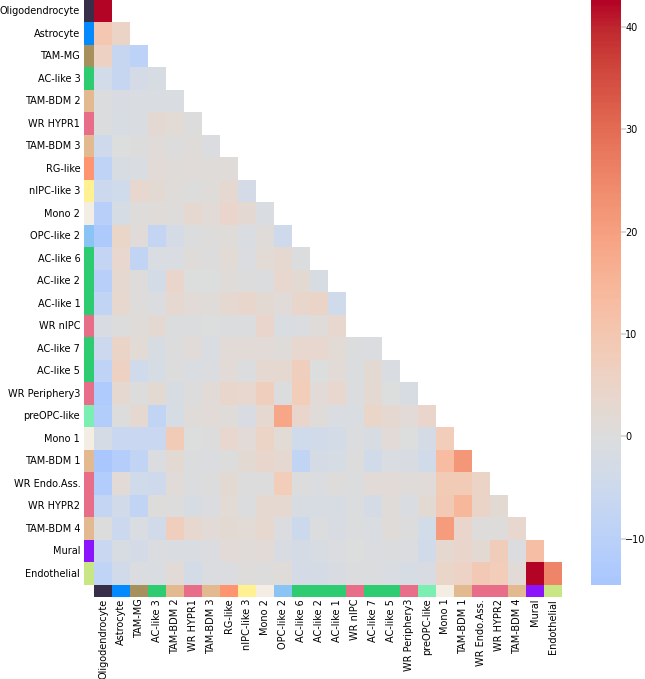

SL001B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

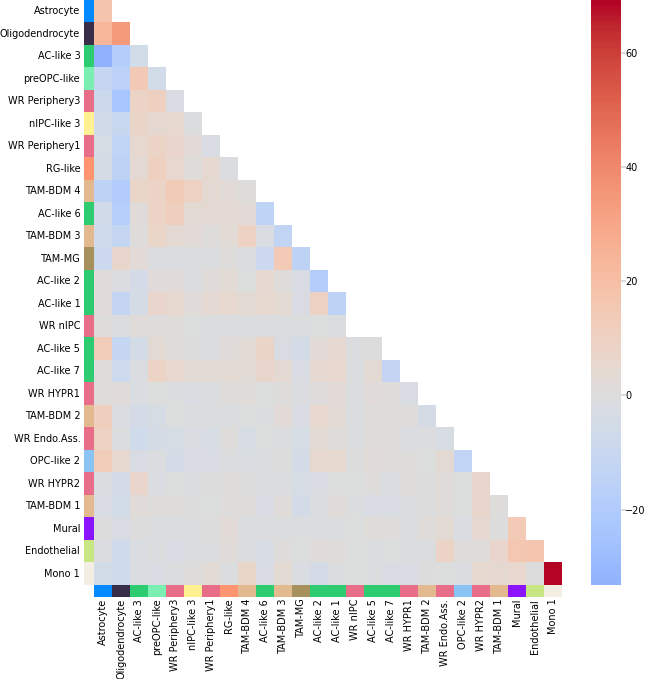

SL002


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

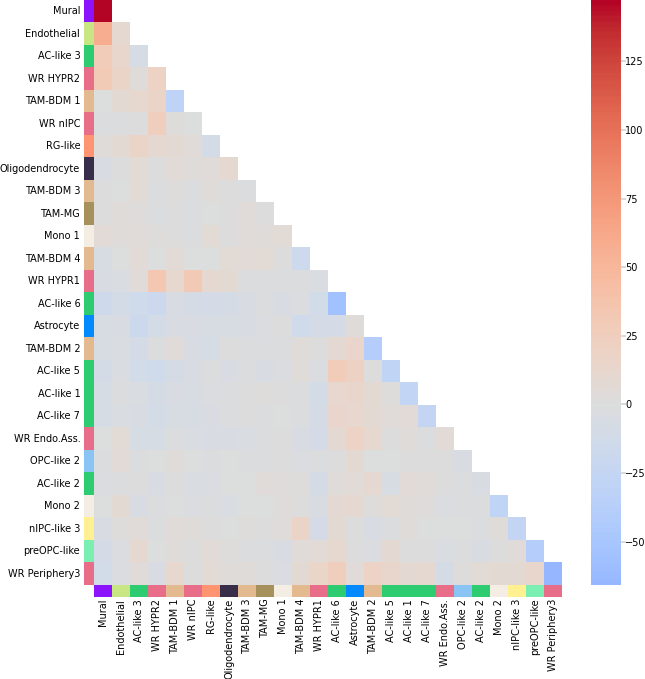

SL003


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

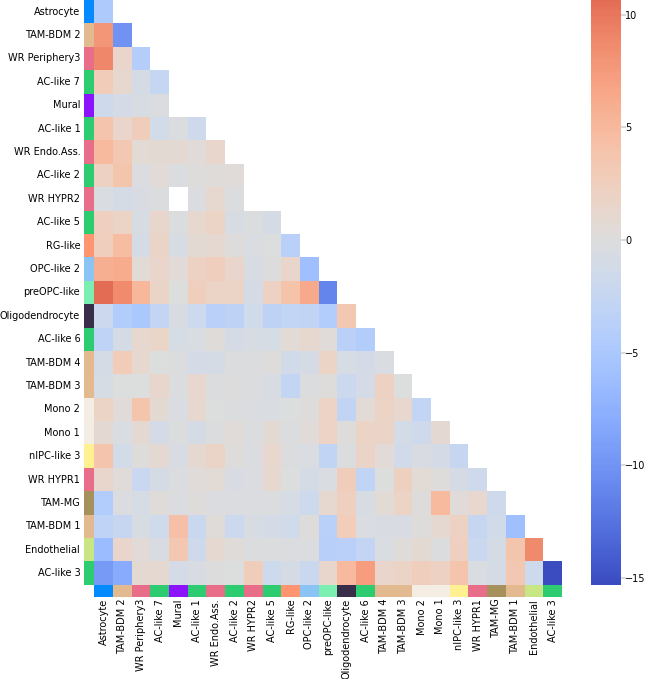

SL005


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

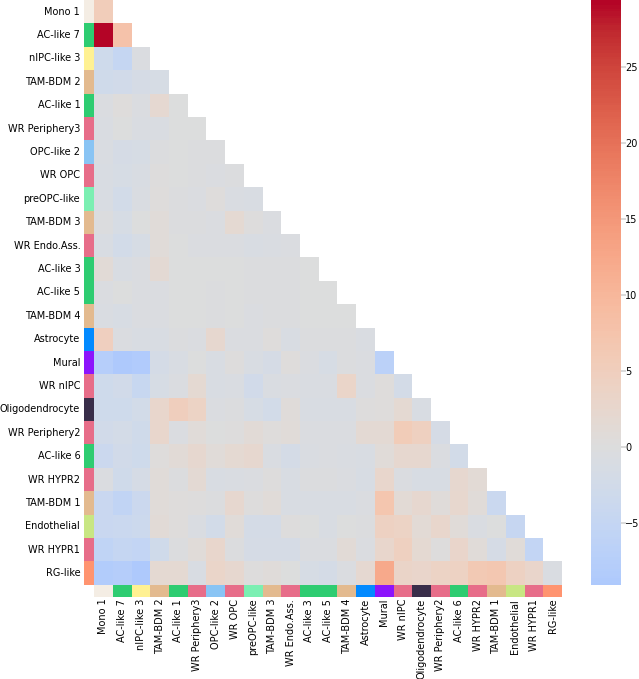

SL006


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

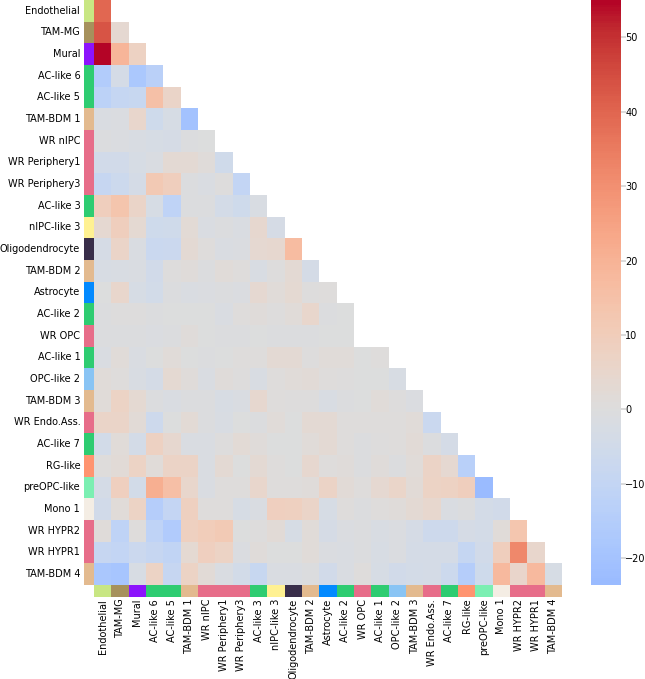

SL011


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

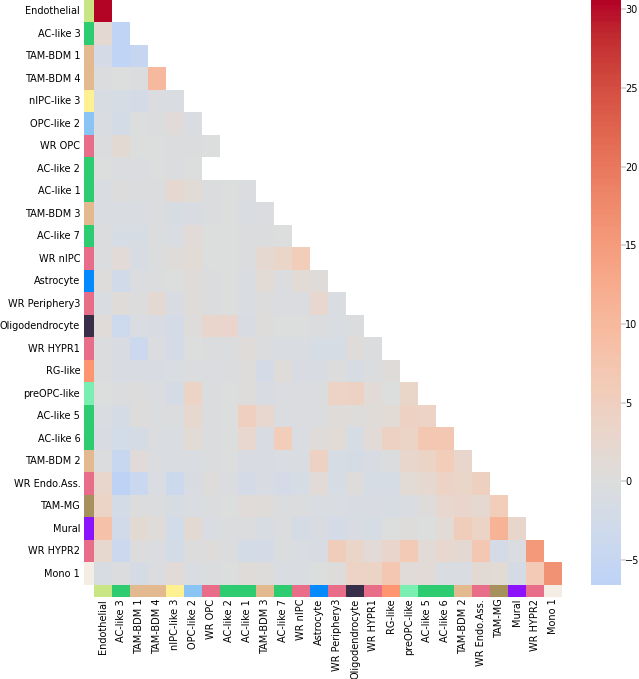

SL012


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

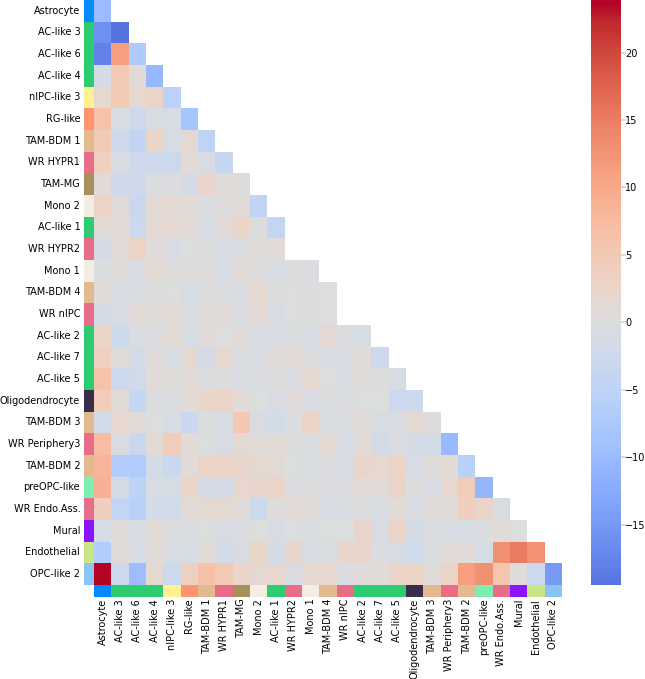

SL013


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

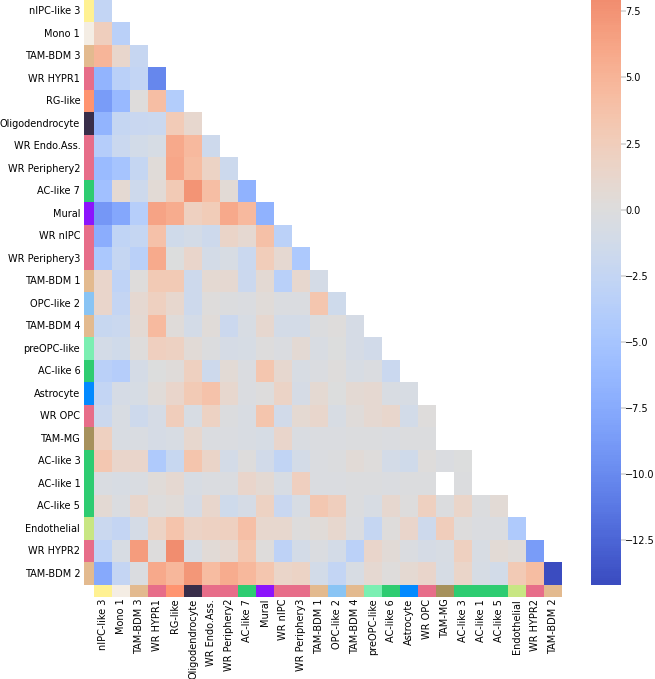

SL015


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

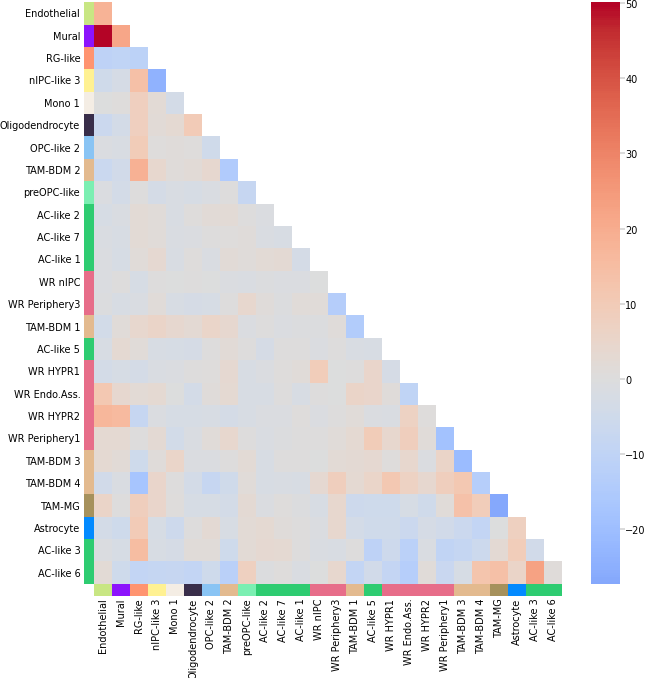

SL016A


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

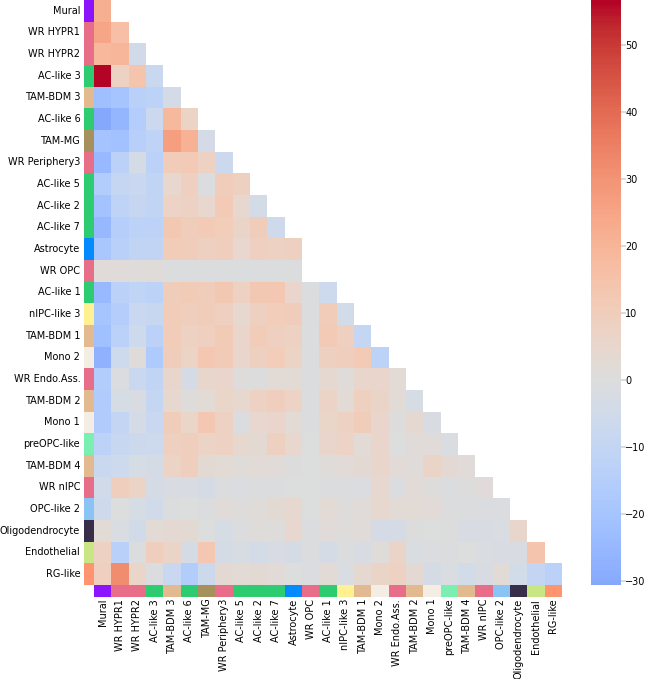

SL016B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

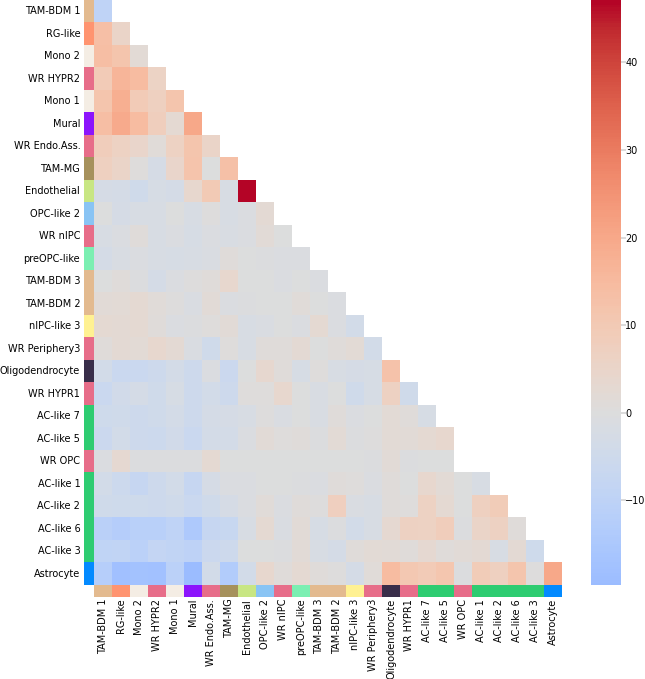

SL018


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

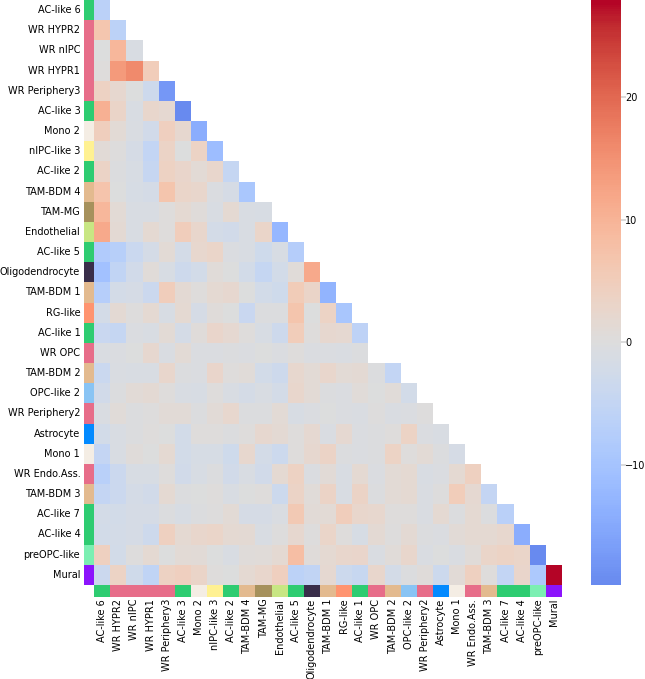

SL019


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

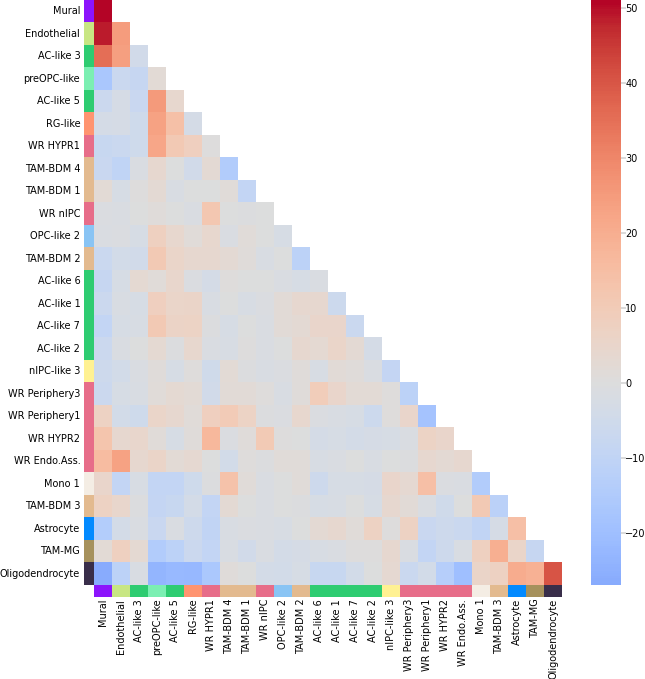

SL020


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

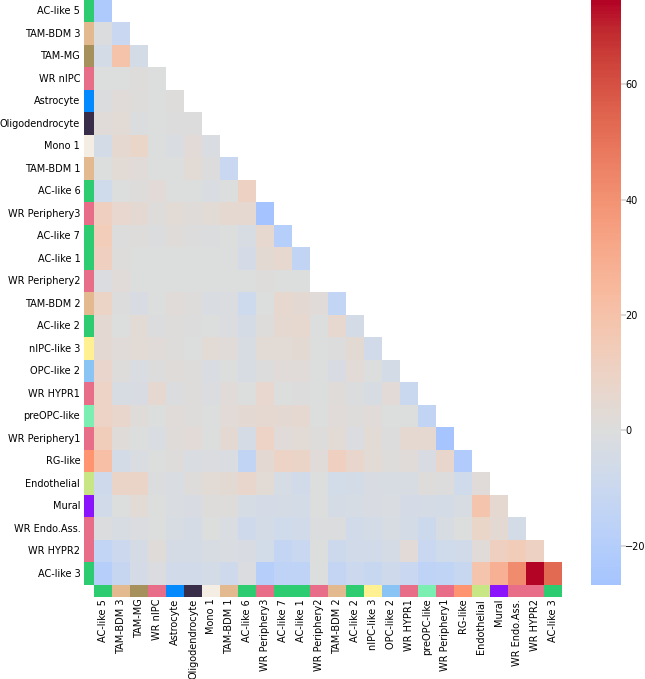

SL023


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

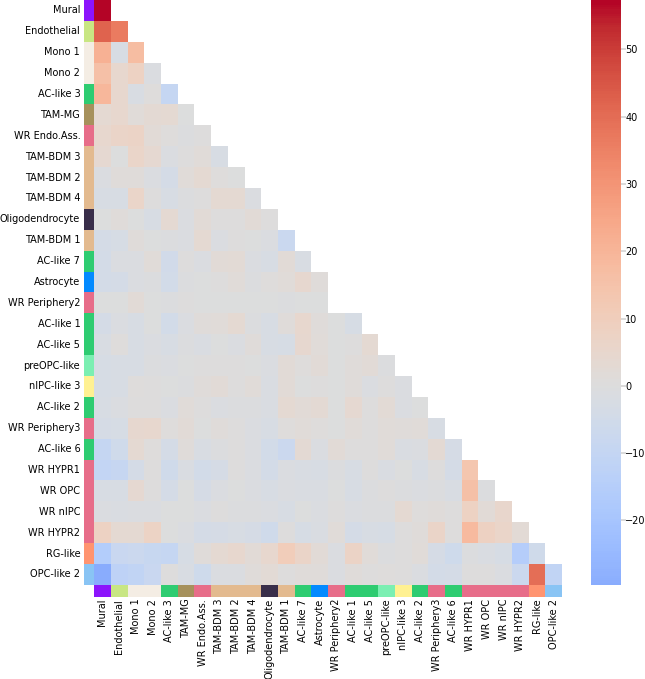

SL027B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

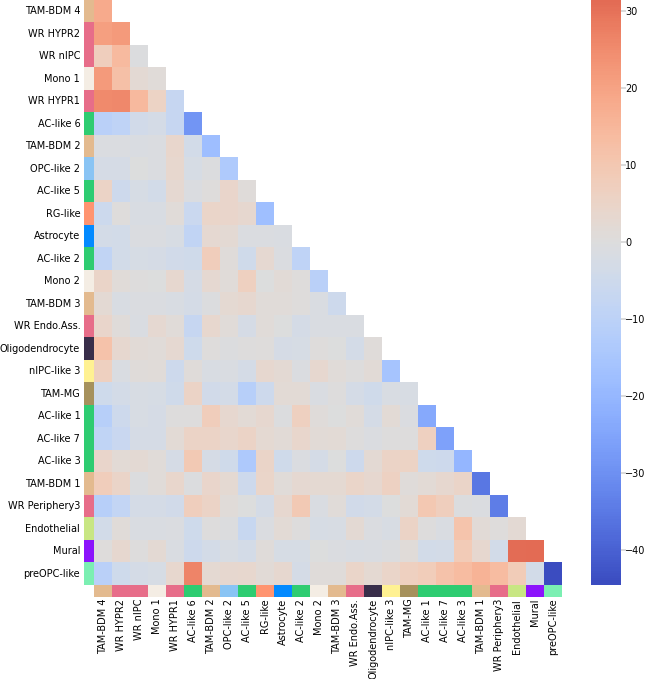

SL029


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

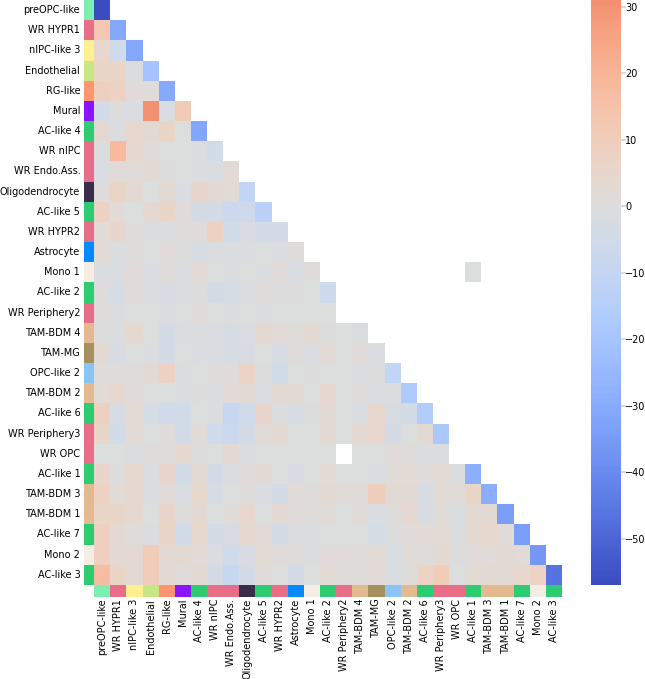

SL030


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

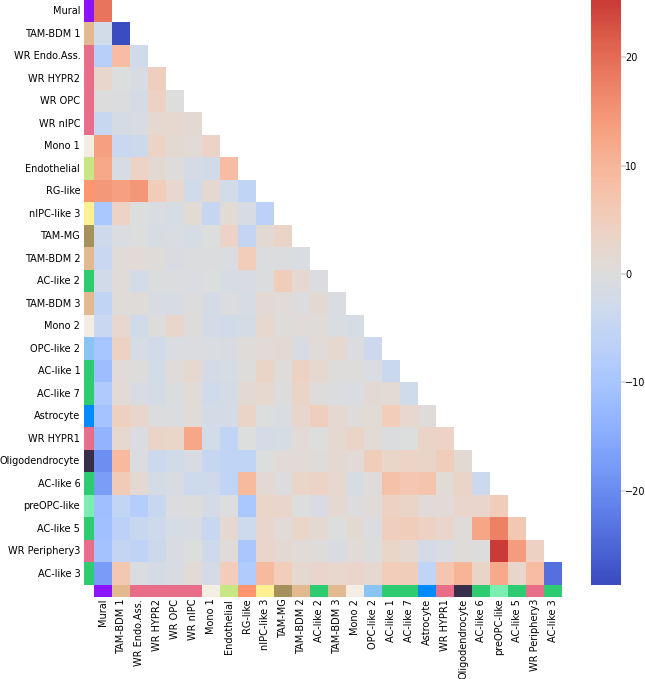

SL034


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

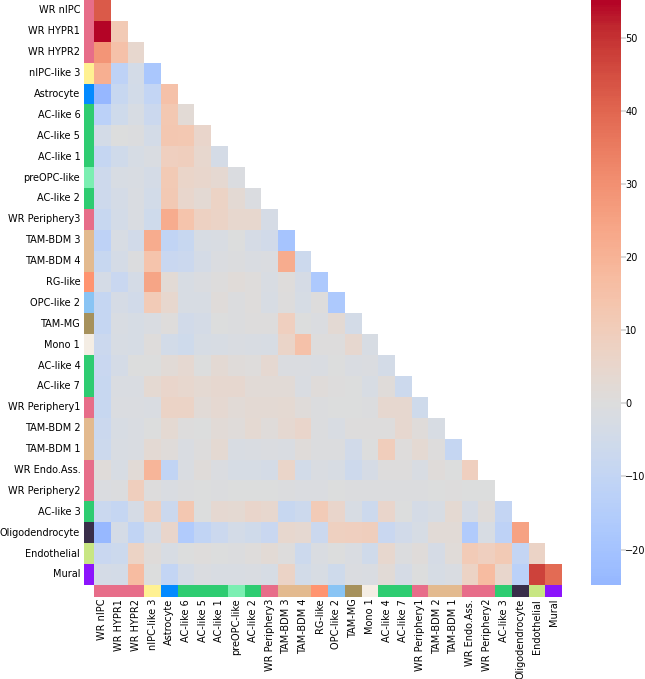

SL035A


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

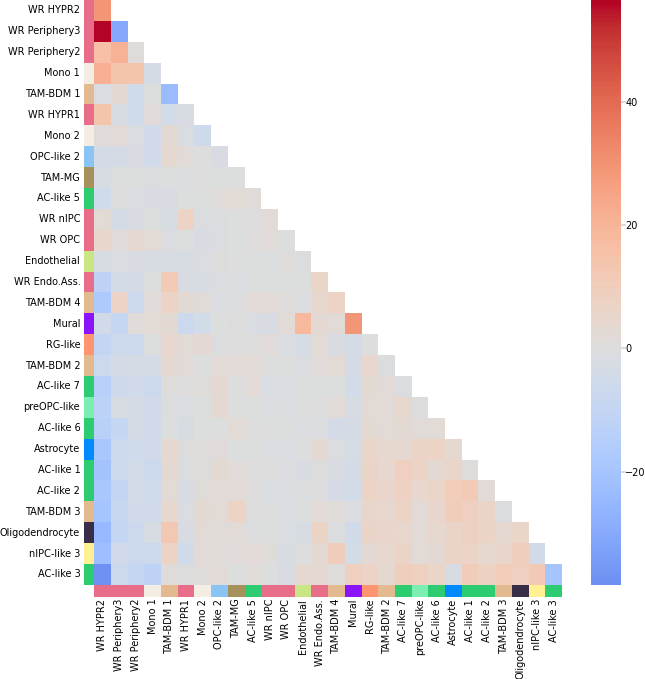

SL035B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

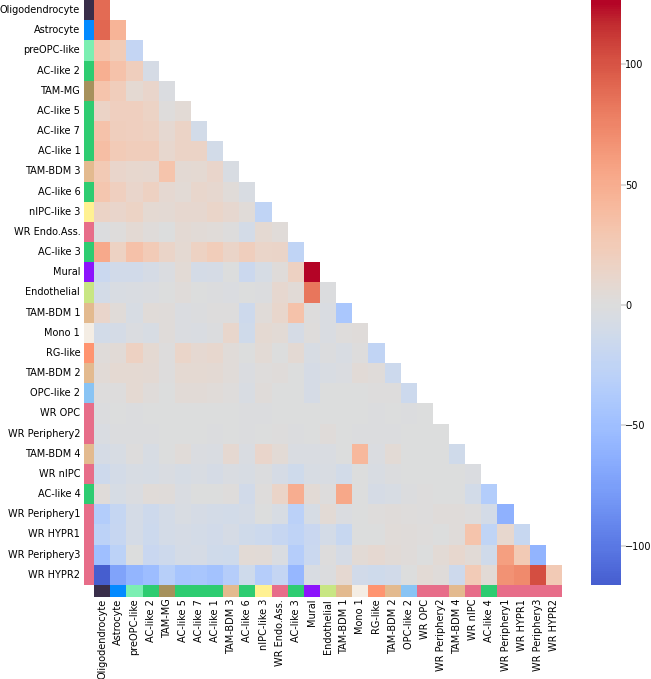

SL037


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

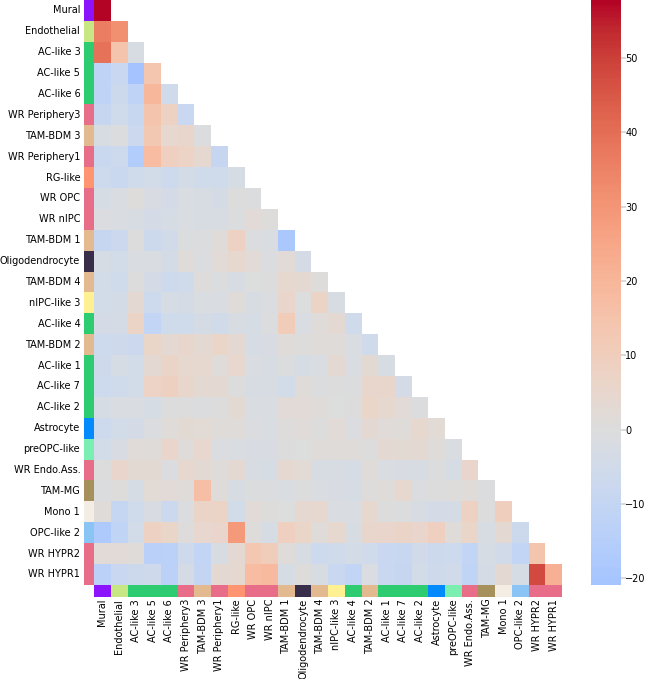

SL038


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

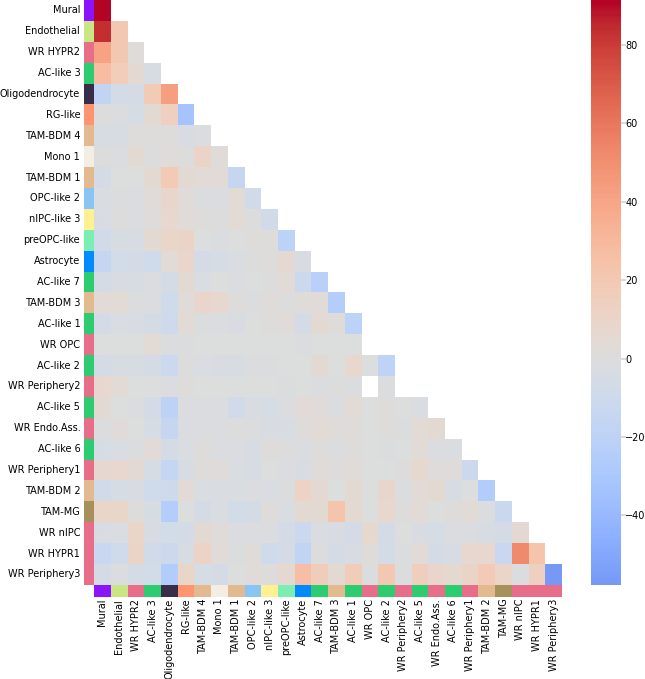

SL040B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

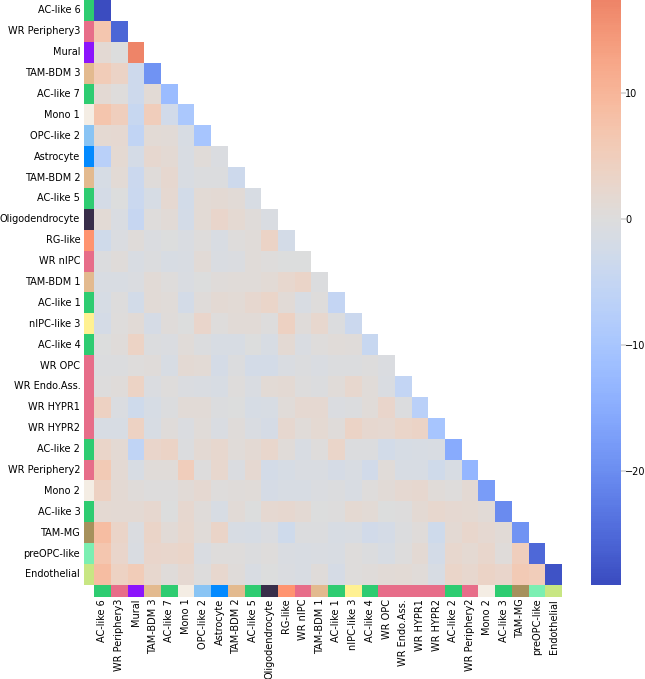

SL040Bulk


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

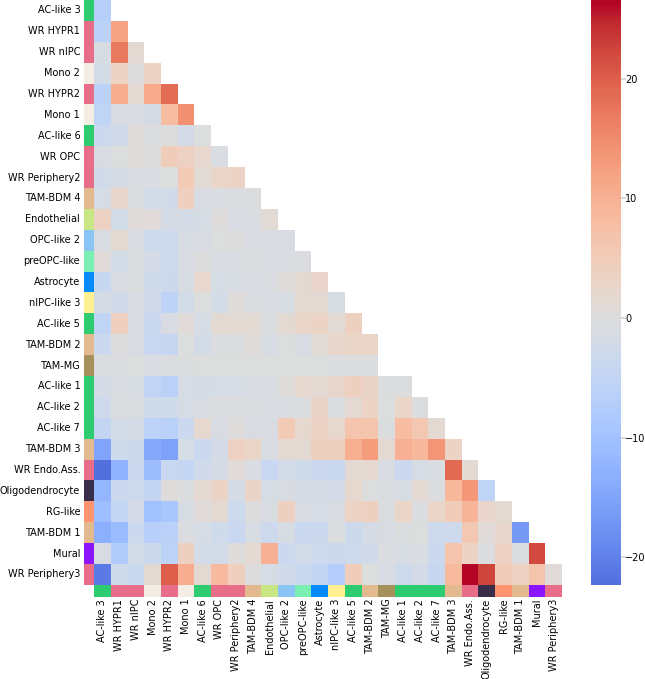

SL040C


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

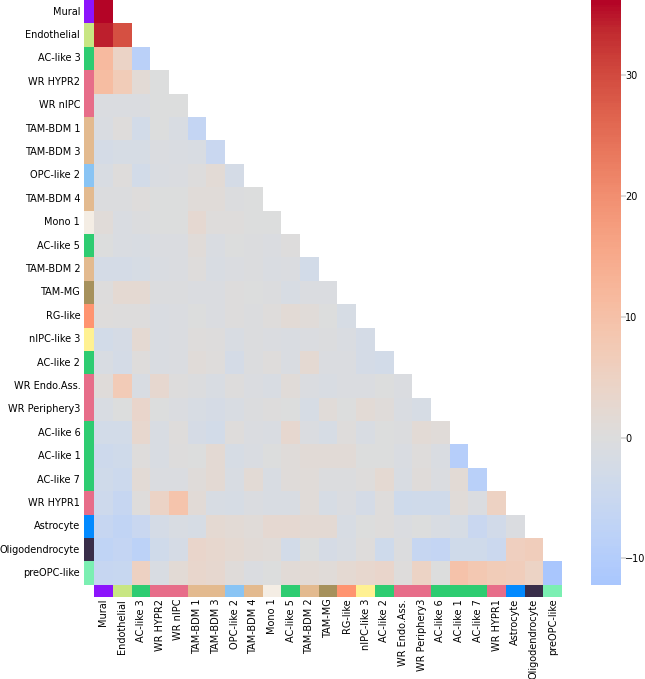

SL040D


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

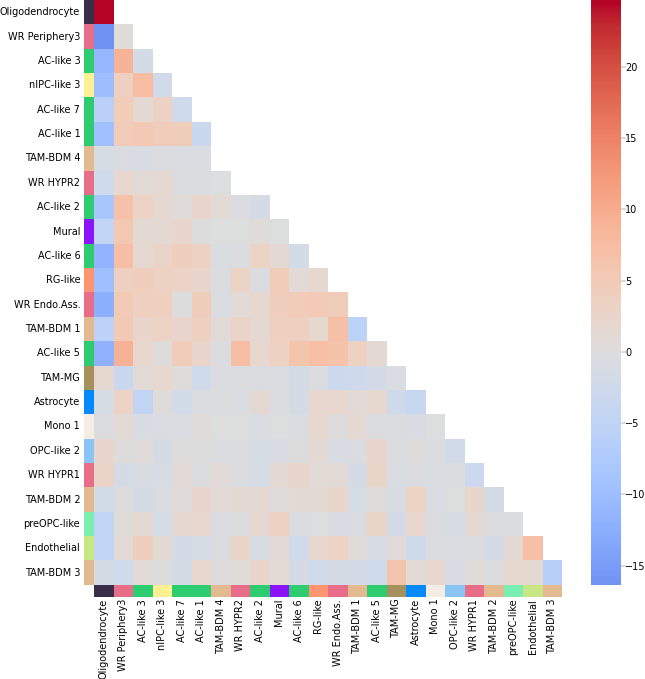

SL040E


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

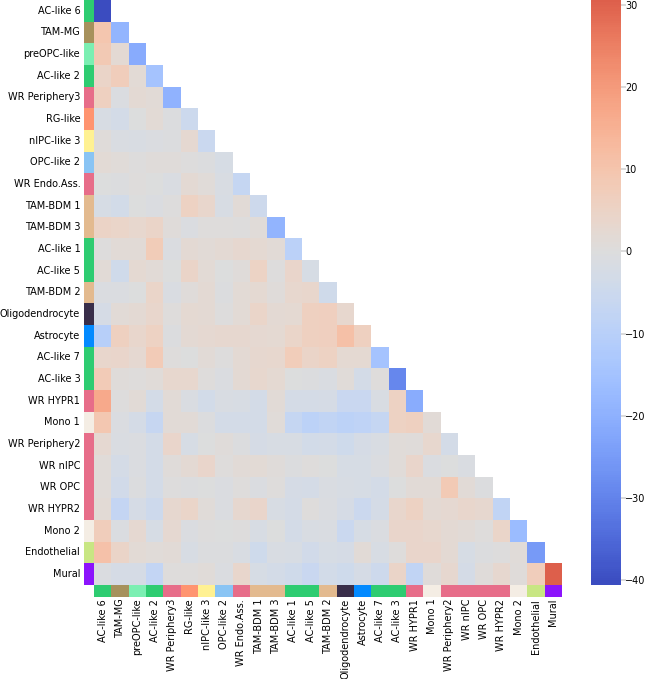

SL040F


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

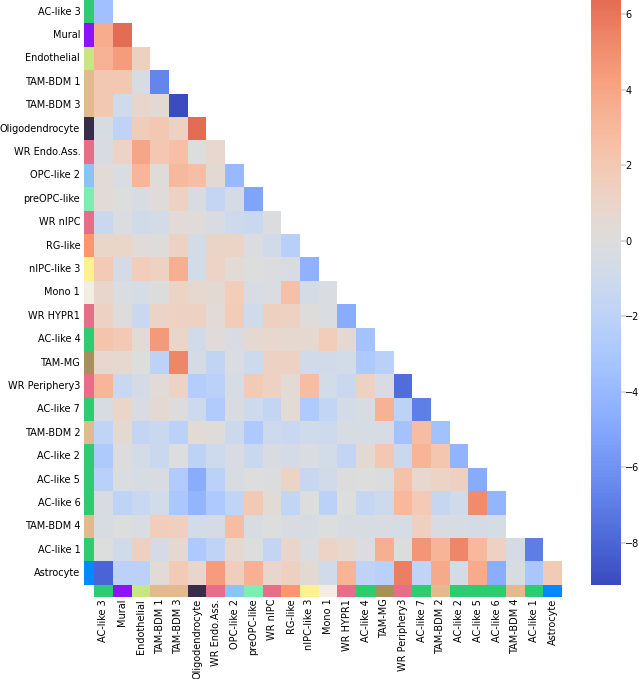

SL040G


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

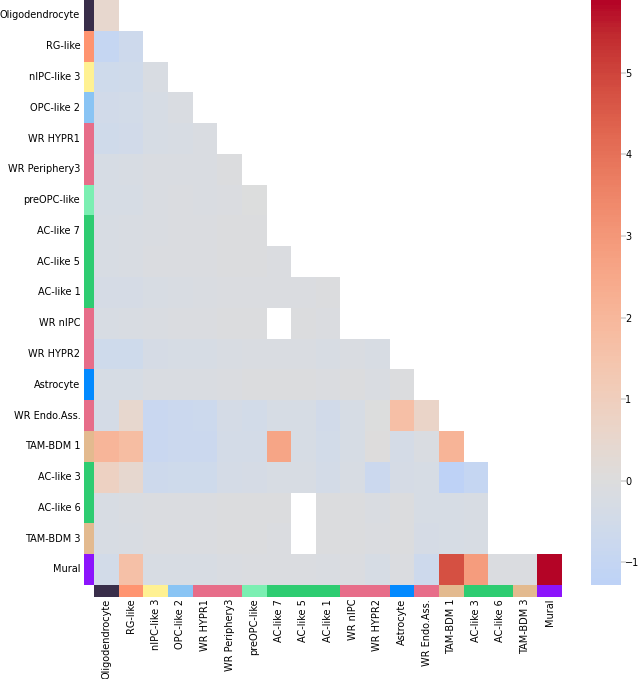

SL046A


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

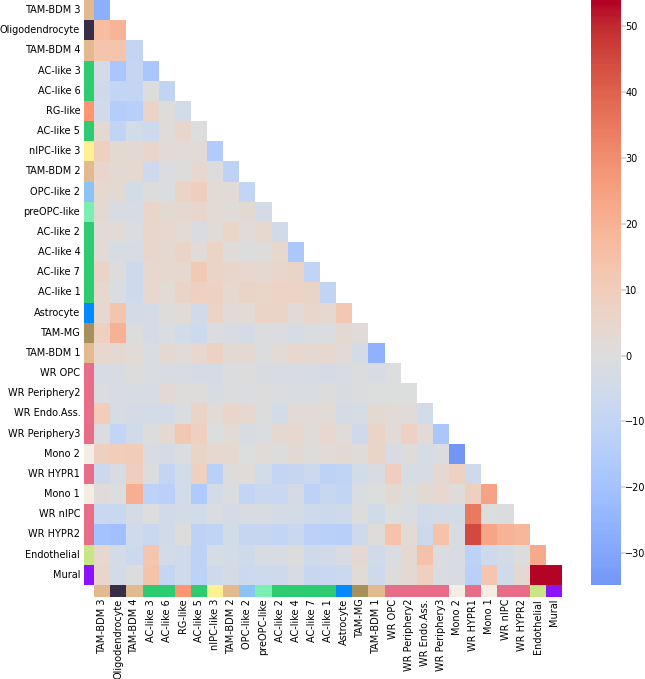

SL046B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

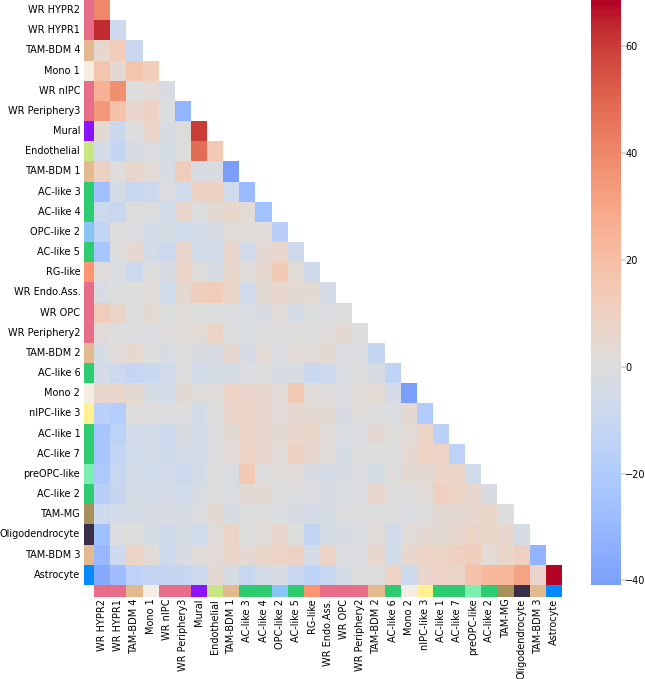

SL046C


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

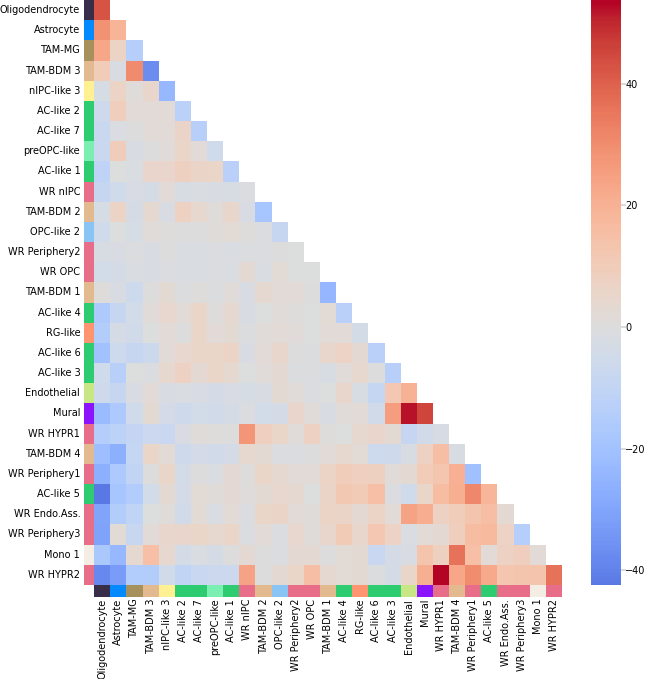

SL047B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

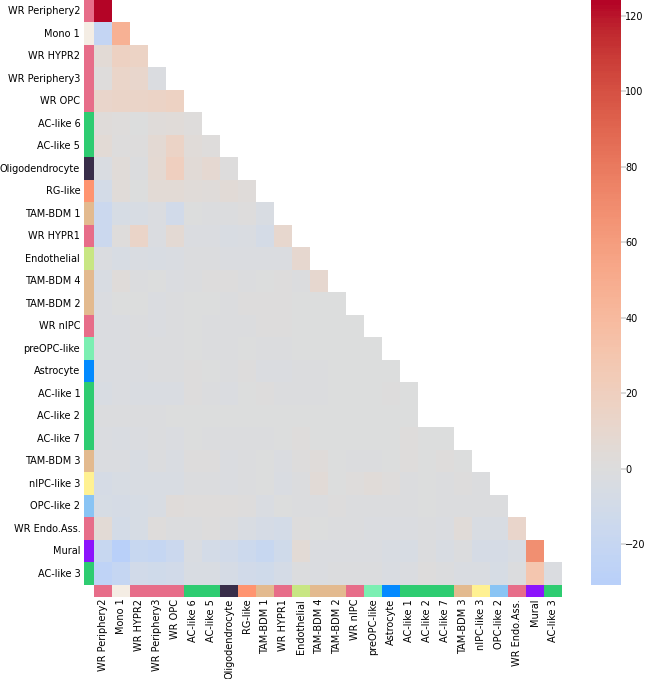

SL053


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

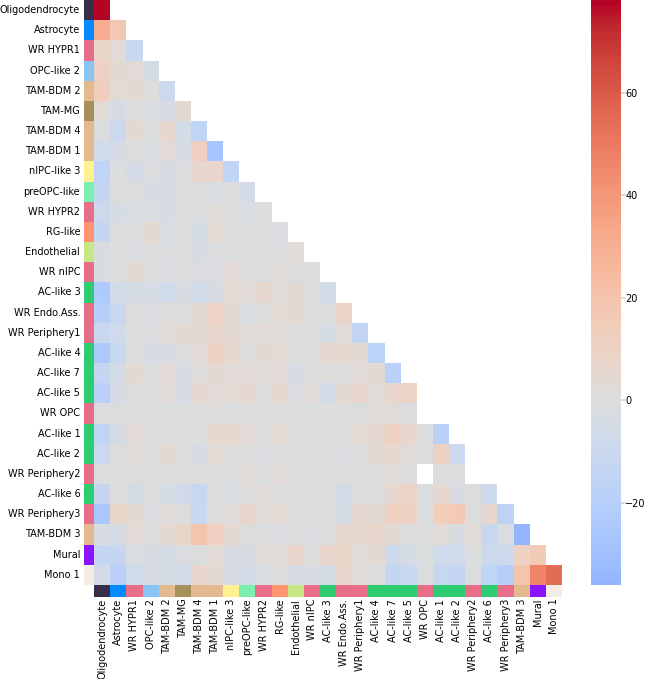

SL057A


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

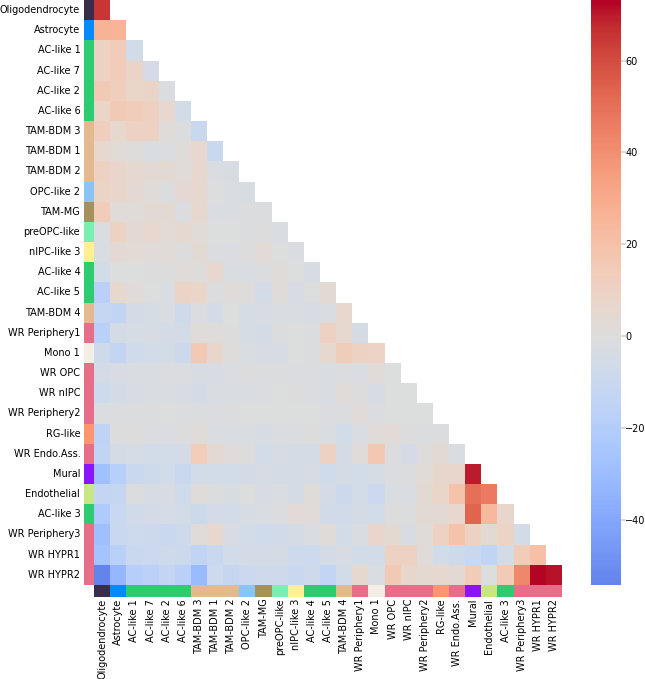

SL057B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

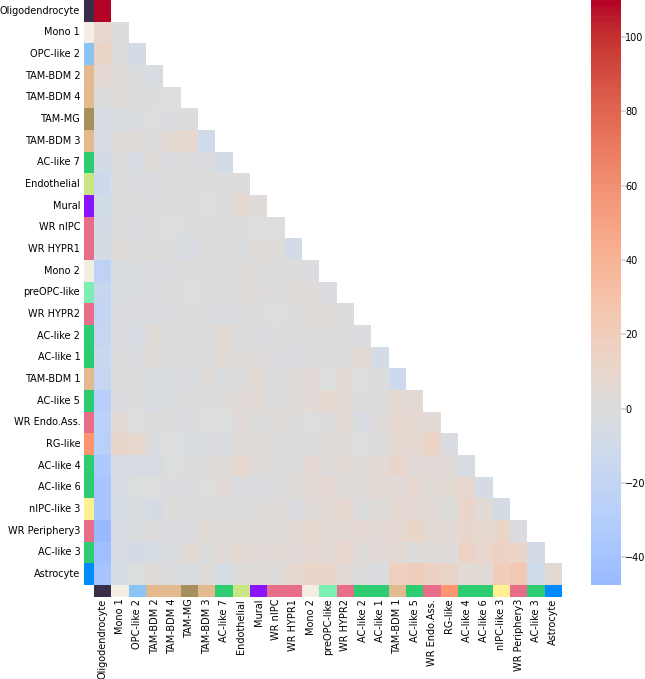

SL061A


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

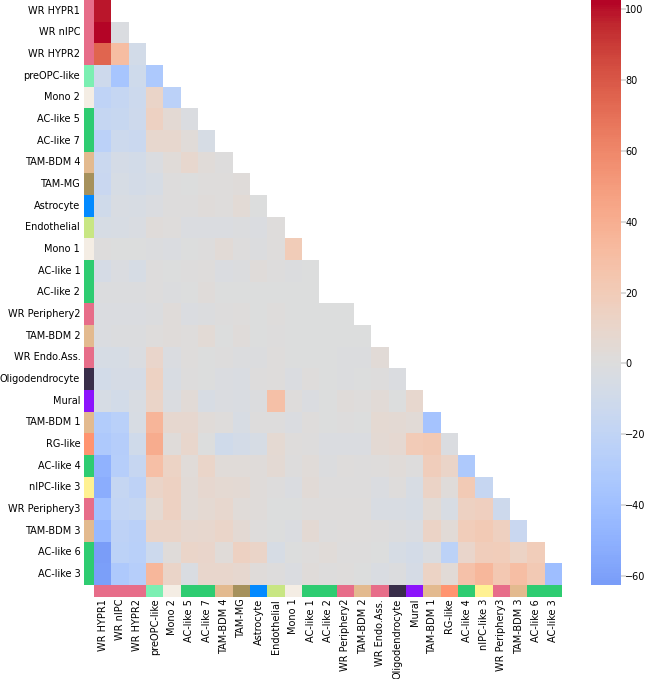

SL061B


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

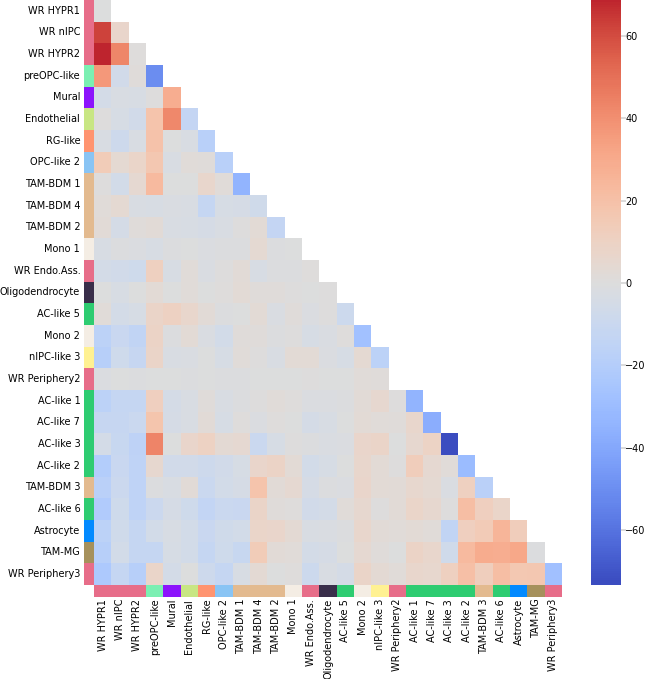

SL061C


  0%|                                                      | 0/1000 [00:00<?, ?/s]/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_te

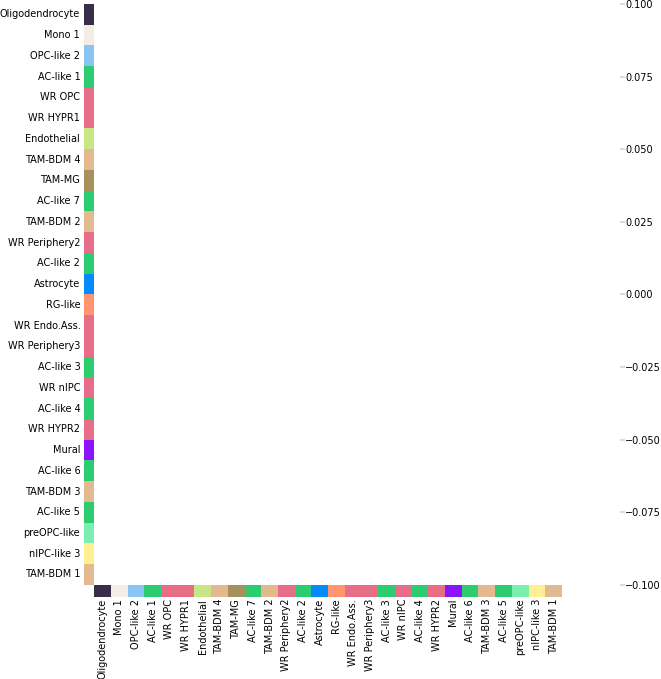

In [13]:
dic_nhood = {} 
samples = []
for s in adata.obs.Sample.cat.categories:
    print(s)
    
    sadata = adata[adata.obs.Sample == s]
    sadata = sadata[sadata.X.sum(axis=1) > 20]
    selected_clusters = list(palette.keys())
    sadata_clusters = sadata[sadata.obs['m-states'].isin(selected_clusters)]
    if len(sadata_clusters.obs['m-states'].cat.categories) > 7:

        #try:
        #kdT = KDTree(sadata.obsm['spatial'])
        #d,i = kdT.query(sadata.obsm['spatial'],k=10)
        #d_th = np.percentile(d[:,-1],95)

        sq.gr.spatial_neighbors(sadata_clusters,coord_type="generic", n_neighs=10,delaunay=True,radius=(2.5,50))
        sq.gr.nhood_enrichment(sadata_clusters, cluster_key="m-states")

        sp.pl.neighborhood_enrichment(
            sadata_clusters, 
            key='m-states',
            palette=palette,
            save=True,
            figsize=(7,7),
            savepath=f'figures/figures_nn/NN_{s}.pdf'
        )

        df = pd.DataFrame(
        data=sadata_clusters.uns['m-states_nhood_enrichment']['zscore'], 
        index=sadata_clusters.obs['m-states'].cat.categories,
        columns=sadata_clusters.obs['m-states'].cat.categories,

        )

        full_df = pd.DataFrame(np.zeros([len(selected_clusters), len(selected_clusters)]), index=selected_clusters, columns=selected_clusters)
        for s1 in selected_clusters:
            for s2 in selected_clusters:
                try:
                    v = df[s1][s2]
                except:
                    v = 0
                full_df[s1][s2] = v
        dic_nhood[s] = full_df
        samples.append(s)
        #except:
        #    print(f'Could not analyse sample {s}')
            



In [15]:
import pickle
pickle.dump(dic_nhood, open('CellStateNN_20240528-2.pkl', 'wb'))